## Exercise - SVM for classification of 10 classes

> 1. Try to split your training data (again using **train_test_split**) to obtain a validation set. Try to optimize the performance of your model on the validation data, by trying different kernels (linear, poly, and rbf), different values of C, different decision function (ovr or ovo), and perhaps even other stuff.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import svm
from sklearn.datasets import load_digits
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [2]:
# Parameter `return_X_y` already returns the subdivision between data and target
X, y = load_digits(return_X_y = True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Cool way to do validation sets, splitting over the already splitted training data
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size = 0.2, random_state = 42)

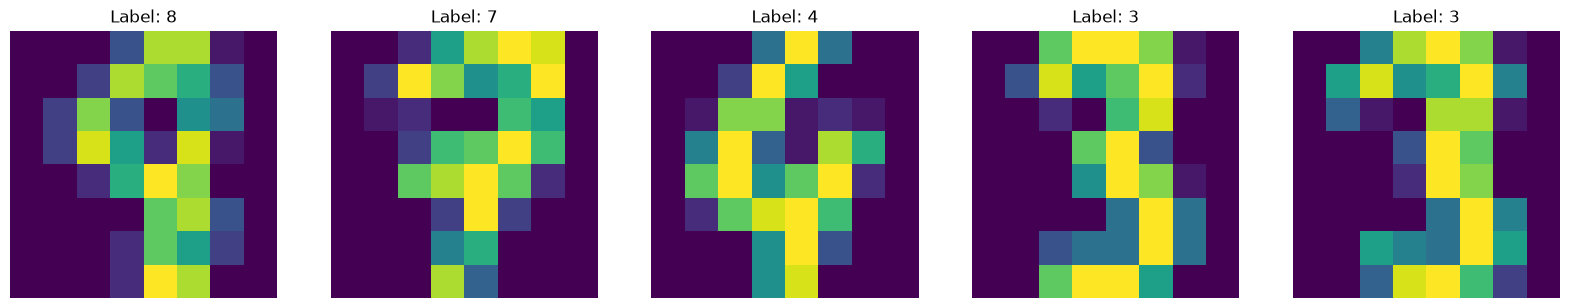

In [11]:
# Let us look at a few of the digits (you do not need to change anything in this block)
num_samples = 5

# Select the first `num_samples` images and their labels from X_train and y_train
images = X_train[:num_samples]
labels = y_train[:num_samples]

# Each row of X is a flattened image (8 x 8 = 64), so we reshape before plotting
fig, axes = plt.subplots(1, num_samples, figsize = (20, 6))
for i, ax in enumerate(axes):
    ax.imshow(images[i].reshape(8, 8))
    ax.set_title(f"Label: {labels[i]}")
    ax.axis("off")

plt.show()

In [ ]:
kernels = ["linear", "poly", "rbf"]
decision_functions = ["ovo", "ovr"]
Cs = [0.00001, 0.001, 0.1, 1, 10, 100]

results = []

for kernel in kernels:
    for C in Cs:
        for decision_function in decision_functions:
            svm_current = svm.SVC(kernel = kernel, C = C, decision_function_shape = decision_function)

            # Fitting done over the training data, not over the validation data
            svm_current.fit(X = X_train, y =  y_train)

            # Prediction done over the validation data, so not `X_test`
            y_val_hat = svm_current.predict(X_val)

            # As ground truth we are taking in account the validation data, so not `y_test`
            accuracy = accuracy_score(y_true = y_val, y_pred = y_val_hat)

            results.append([accuracy, kernel, C, decision_function])

In [28]:
df_linear = pd.DataFrame(columns = ["Accuracy", "C", "Decision Function"])
df_poly = pd.DataFrame(columns = ["Accuracy", "C", "Decision Function"])
df_rbf = pd.DataFrame(columns = ["Accuracy", "C", "Decision Function"])

dict_df = {"linear": df_linear, "poly": df_poly, "rbf": df_rbf}

for result in results:
    df = dict_df.get(result[1])
    df.loc[len(df)] = [result[0], result[2], result[3]]

print("Linear Kernel Dataframe")
display(df_linear)

print("Polynomial Kernel Dataframe")
display(df_poly)

print("Radial Kernel Dataframe")
display(df_rbf)

Linear Kernel Dataframe


,Accuracy,C,Decision Function
0,0.399306,0.00001,ovo
1,0.399306,0.00001,ovr
2,0.986111,0.00100,ovo
3,0.986111,0.00100,ovr
4,0.993056,0.10000,ovo
5,0.993056,0.10000,ovr
6,0.993056,1.00000,ovo
7,0.993056,1.00000,ovr
8,0.993056,10.00000,ovo
9,0.993056,10.00000,ovr


Polynomial Kernel Dataframe


,Accuracy,C,Decision Function
0,0.072917,0.00001,ovo
1,0.072917,0.00001,ovr
2,0.072917,0.00100,ovo
3,0.072917,0.00100,ovr
4,0.986111,0.10000,ovo
5,0.986111,0.10000,ovr
6,0.996528,1.00000,ovo
7,0.996528,1.00000,ovr
8,1.000000,10.00000,ovo
9,1.000000,10.00000,ovr


Radial Kernel Dataframe


,Accuracy,C,Decision Function
0,0.072917,0.00001,ovo
1,0.072917,0.00001,ovr
2,0.072917,0.00100,ovo
3,0.072917,0.00100,ovr
4,0.940972,0.10000,ovo
5,0.940972,0.10000,ovr
6,1.000000,1.00000,ovo
7,1.000000,1.00000,ovr
8,1.000000,10.00000,ovo
9,1.000000,10.00000,ovr


In [35]:
print("Linear Kernel Dataframe")
display(df_linear[df_linear["Accuracy"] == df_linear["Accuracy"].max()])

print("Polynomial Kernel Dataframe")
display(df_poly[df_poly["Accuracy"] == df_poly["Accuracy"].max()])

print("Radial Kernel Dataframe")
display(df_rbf[df_rbf["Accuracy"] == df_rbf["Accuracy"].max()])

Linear Kernel Dataframe


,Accuracy,C,Decision Function
4,0.993056,0.1,ovo
5,0.993056,0.1,ovr
6,0.993056,1.0,ovo
7,0.993056,1.0,ovr
8,0.993056,10.0,ovo
9,0.993056,10.0,ovr
10,0.993056,100.0,ovo
11,0.993056,100.0,ovr


Polynomial Kernel Dataframe


,Accuracy,C,Decision Function
8,1.0,10.0,ovo
9,1.0,10.0,ovr
10,1.0,100.0,ovo
11,1.0,100.0,ovr


Radial Kernel Dataframe


,Accuracy,C,Decision Function
6,1.0,1.0,ovo
7,1.0,1.0,ovr
8,1.0,10.0,ovo
9,1.0,10.0,ovr
10,1.0,100.0,ovo
11,1.0,100.0,ovr


In [37]:
svm_optimized = svm.SVC(kernel = "rbf", C = 1.0, decision_function_shape = "ovo") 

# Concatenating in an unique ndarray data coming from training and validation
svm_optimized.fit(np.concatenate([X_train, X_val]), np.concatenate([y_train, y_val]))

y_test_hat_optimized = svm_optimized.predict(X_test)

accuracy_optimized = accuracy_score(y_test, y_test_hat_optimized)
print(f"Optimized SVM achieved {round(accuracy_optimized * 100, 1)}% accuracy.")

Optimized SVM achieved 98.6% accuracy.
